## Tarea 7 Métodos Numéricos
# Desafío Clima con Cadenas de Markov

En este desafío, usaremos cadenas de Markov para predecir patrones de clima en Chile, basado en datos históricos a lo largo de los años de parte de la Dirección Meteorológica de Chile.

Para esto, primero extraeremos los datos, y usaremos un DataFrame de Pandas para guardar esta información y usarla para crear cadenas de Markov.
Usaremos datos de la estación ubicada en Quinta Normal, con un código de 330020.
Originalmente, pensé usar datos de 1980 a 2025... sin embargo, creo que algo interesante sería lo siguiente: comparar los resultados obtenidos desde 1960 hasta 1991, a los resultados obtenidos desde 2015 a 2025. 

En los últimos 10 años, la temperatura promedio de cada día en Chile ha subido rápidamente. El propósito de este trabajo es **ver como cambian las cadenas de Markov si comparamos los datos antiguos con los datos de los últimos 10 años.** 

Para hacer esto, crearemos tres categorías de temperatura, analizando la temperatura maxima anual:<br>
Frio: **0-16°C**<br>
Templado: **17-25°C**<br>
Caluroso: **26°+C**<br>


## Extraccion y preparacion de datos


In [157]:
import urllib.request as ureq
import pandas as pd
import numpy as np

variables = ["temperaturaMaximaAnual"] # lista en caso de agregar mas variables
years1 = list(range(1960, 1991))
years2 = list(range(2015, 2026))
estacion = 330020


urlbase = "https://climatologia.meteochile.gob.cl/application/anual"

# datos 1960 a 1990
datosYears1 = []
for v in variables:
    for a in years1:
        url = f"{urlbase}/{v}/{estacion}/{a}"
        try:
            with ureq.urlopen(url) as pagina:
                # Decodificamos a utf-8 para que sea string
                contenido = pagina.read().decode('utf-8')
                datosYears1.append({"variable": v, "year": a, "html": contenido})
        except Exception as e:
            print(f"Error en {a}: {e}")

# datos 2015 a 2025
datosYears2 = []
for v in variables:
    for a in years2:
        url = f"{urlbase}/{v}/{estacion}/{a}"
        try:
            with ureq.urlopen(url) as pagina:
                contenido = pagina.read().decode('utf-8')
                datosYears2.append({"variable": v, "year": a, "html": contenido})
        except Exception as e:
            print(f"Error en {a}: {e}")

In [223]:
def procesar_html_extraido(lista_html):
    registros_finales = []
    
    for entrada in lista_html:
        year = entrada['year']
        variable = entrada['variable']
        html = entrada['html']
        fragmentos = html.split('<td class="text-center">')

        fragmentos = fragmentos[1:]
        
        valores = [f.split('</td>')[0].strip() for f in fragmentos]
        
        for i in range(0, len(valores), 13):
            fila = valores[i : i + 13]
            if not fila: continue
            
            dia = fila[0] # primer valor corresponde al numero del dia
            
            # Recorremos los meses (posiciones 1 a 12)
            for mes_idx in range(1, 13):
                valor_clima = fila[mes_idx]
                
                # Filtrar celdas vacías, guiones o saltos de línea
                if valor_clima and valor_clima not in ['-', '', '&nbsp;', '\n']:
                    try:
                        registros_finales.append({
                            'fecha': f"{year}-{mes_idx:02d}-{int(dia):02d}",
                            'mes': mes_idx,
                            'temperatura': float(valor_clima),
                        })
                    except ValueError:
                        continue 
                        
    return registros_finales


datos_limpios_1 = procesar_html_extraido(datosYears1)
datos_limpios_2 = procesar_html_extraido(datosYears2) 

df1 = pd.DataFrame(datos_limpios_1)
df2 = pd.DataFrame(datos_limpios_2)
display(df1.head())
display(df2.head())

,fecha,mes,temperatura
0,1960-01-01,1,21.8
1,1960-02-01,2,31.4
2,1960-03-01,3,30.1
3,1960-04-01,4,28.8
4,1960-05-01,5,24.4


,fecha,mes,temperatura
0,2015-01-01,1,30.2
1,2015-02-01,2,32.6
2,2015-03-01,3,29.8
3,2015-04-01,4,30.6
4,2015-05-01,5,19.4


In [159]:
'''
Frio: **0-16°C**
Templado: **17-25°C**
Caluroso: **26+°C**
'''

df1['Estado'] = pd.cut(df1['temperatura'], bins=[-np.inf, 16, 25, np.inf], labels=['Frio', 'Templado', 'Caluroso'])
display(df1)

df2['Estado'] = pd.cut(df2['temperatura'], bins=[-np.inf, 16, 25, np.inf], labels=['Frio', 'Templado', 'Caluroso'])
display(df2)

,fecha,mes,temperatura,Estado
0,1960-01-01,1,21.8,Templado
1,1960-02-01,2,31.4,Caluroso
2,1960-03-01,3,30.1,Caluroso
3,1960-04-01,4,28.8,Caluroso
4,1960-05-01,5,24.4,Templado
...,...,...,...,...
11285,1990-05-31,5,16.4,Templado
11286,1990-07-31,7,21.6,Templado
11287,1990-08-31,8,10.8,Frio
11288,1990-10-31,10,24.2,Templado


,fecha,mes,temperatura,Estado
0,2015-01-01,1,30.2,Caluroso
1,2015-02-01,2,32.6,Caluroso
2,2015-03-01,3,29.8,Caluroso
3,2015-04-01,4,30.6,Caluroso
4,2015-05-01,5,19.4,Templado
...,...,...,...,...
4012,2025-05-31,5,20.9,Templado
4013,2025-07-31,7,15.3,Frio
4014,2025-08-31,8,15.2,Frio
4015,2025-10-31,10,23.8,Templado


Con los dias etiquetados, podemos ahora crear matrices de transicion, 1 para cada mes. 


### Creacion de Cadenas de Markov

In [160]:
import numpy as np

def calcular_matriz_transicion(df_mes):
    estados = ['Frio', 'Templado', 'Caluroso']
    matriz3x3 = np.zeros((3, 3))
    
    # Mapeamos los nombres a índices (0, 1, 2)
    mapa = {estado: i for i, estado in enumerate(estados)}
    
    # Creamos una columna con el estado del día anterior
    # Solo funciona si los datos están ordenados por fecha
    estado_hoy = df_mes['Estado'].values
    estado_ayer = df_mes['Estado'].shift(1).values
    
    # Recorremos los datos contando las transiciones
    for i in range(1, len(estado_hoy)):
        actual = estado_hoy[i]
        anterior = estado_ayer[i]
        f = mapa[anterior] # fila
        c = mapa[actual] # columna
        matriz3x3[f][c] += 1
            
    # Dividir fila por su suma para conseguir una probabilidad
    matriz_prob = np.copy(matriz3x3)
    for i in range(len(estados)):
        suma_fila = np.sum(matriz3x3[i])
        if suma_fila > 0:
            matriz_prob[i] = matriz3x3[i] / suma_fila
    return matriz_prob

matrices_era1 = {}
matrices_era2 = {}
for mes in range(1, 13):    
    df1_filtrado = df1[df1['mes'] == mes]
    df2_filtrado = df2[df2['mes'] == mes]
    matrices_era1[mes] = calcular_matriz_transicion(df1_filtrado)
    matrices_era2[mes] = calcular_matriz_transicion(df2_filtrado)



Esto nos da nuestras 12 matrices de transicion por era, 1 para cada mes, agrupadas en un gran diccionario.

Segun las instrucciones, debemos correr simulaciones de Montecarlo para cada una de estas 12 matrices por era. Entonces, separemos las matrices:

In [161]:
# Periodo 1
eneroEra1   = matrices_era1[1]
febreroEra1 = matrices_era1[2]
marzoEra1   = matrices_era1[3]
abrilEra1   = matrices_era1[4]
mayoEra1    = matrices_era1[5]
junioEra1   = matrices_era1[6]
julioEra1   = matrices_era1[7]
agostoEra1  = matrices_era1[8]
septiembreEra1 = matrices_era1[9]
octubreEra1  = matrices_era1[10]
noviembreEra1 = matrices_era1[11]
diciembreEra1 = matrices_era1[12]

# Periodo 2
eneroEra2   = matrices_era2[1]
febreroEra2 = matrices_era2[2]
marzoEra2   = matrices_era2[3]
abrilEra2   = matrices_era2[4]
mayoEra2    = matrices_era2[5]
junioEra2   = matrices_era2[6]
julioEra2   = matrices_era2[7]
agostoEra2  = matrices_era2[8]
septiembreEra2 = matrices_era2[9]
octubreEra2  = matrices_era2[10]
noviembreEra2 = matrices_era2[11]
diciembreEra2 = matrices_era2[12]


In [162]:
# Algunos ejemplos:
display(junioEra2)
display(junioEra1)

display(eneroEra2)
display(eneroEra1)


array([[0.66049383, 0.33950617, 0.        ],
       [0.32298137, 0.64596273, 0.0310559 ],
       [0.5       , 0.33333333, 0.16666667]])

array([[0.74734982, 0.25088339, 0.00176678],
       [0.3971831 , 0.58873239, 0.01408451],
       [0.33333333, 0.66666667, 0.        ]])

array([[0.        , 0.        , 0.        ],
       [0.        , 0.18181818, 0.81818182],
       [0.        , 0.02735562, 0.97264438]])

array([[0.        , 0.        , 0.        ],
       [0.        , 0.22      , 0.78      ],
       [0.        , 0.04198895, 0.95801105]])

In [163]:
import random

def tempDays(currentState, mes, matrix):
    # Definimos la matriz de transición
    mes = int(mes)
    transition_matrix = matrix
    tempStates = ['Frio', 'Templado', 'Caluroso']
    results = [tempStates[currentState]]
    # Calculo de dias del mes para la iteracion
    diasMes = 30 if mes in [4, 6, 9, 11] else 31
    if mes == 2: 
        diasMes = 28


    for i in range(diasMes):
        # seleccion aleatoria con probabilidad de acuerdo a la matríz de transición
        p_row = transition_matrix[currentState]
        p_row = p_row / p_row.sum()
        currentState = np.random.choice([0, 1, 2], p=p_row)
        results.append(tempStates[currentState])
    return results

def Montecarlo(currentState, mes, matrix, runs):
    # solo guardare la prediccion del último día
    print(currentState)
    last_day=[]
    for k in range(runs):
        results = tempDays(currentState, mes, matrix)
        last_day.append(results[-1])
    return last_day

Con las funciones formadas, nuestra labor ahora seria:
- Calcular simulaciones a lo largo de 100 años para cada periodo de tiempo para cada mes
- Graficar estas simulaciones

Veamos si funciona en primer lugar nuestra simulacion con un ejemplo:
 

In [164]:
# Ejemplo para 1000 simulaciones del último día de enero en la Era 1960-1990
from collections import Counter

simulacion_enero = Montecarlo(2, 1, eneroEra1, 1000)
counts = Counter(simulacion_enero)

print(counts)

2
Counter({'Caluroso': 938, 'Templado': 62})


Para graficar esto, podemos simplemente usar boxplots, y debemos modificar un poco nuestra funcion de Montecarlo ya que esta solo guarda los resultados del ultimo dia del mes.

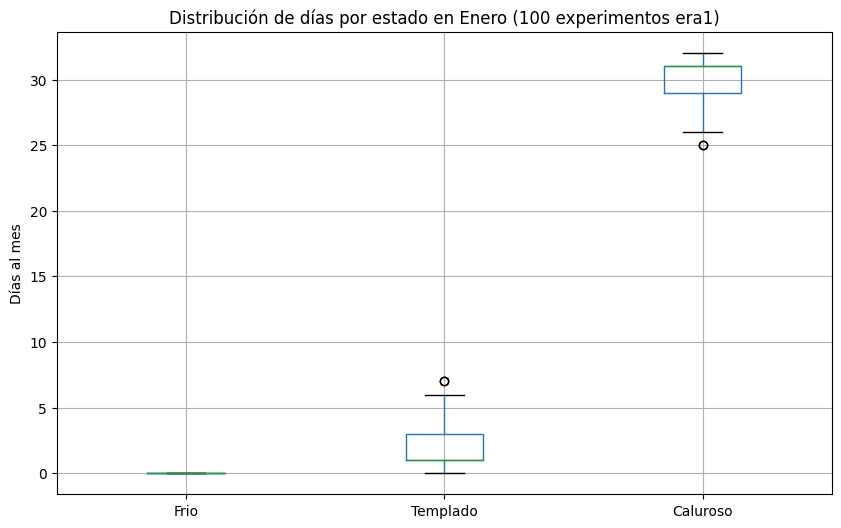

,Frio,Templado,Caluroso
count,0,3.0,29.0
count,0,0.0,32.0
count,0,2.0,30.0
count,0,5.0,27.0
count,0,0.0,32.0
...,...,...,...
count,0,7.0,25.0
count,0,7.0,25.0
count,0,2.0,30.0
count,0,0.0,32.0


In [165]:
import matplotlib.pyplot as plt

def MontecarloParaBoxplot(currentState, mes, matrix, runs):
    totalResults = []
    
    for k in range(runs):
        results = tempDays(currentState, mes, matrix)
        
        counts = pd.Series(results).value_counts()
        totalResults.append(counts)

        
    df_res = pd.DataFrame(totalResults).fillna(0)
    
    # por si algun estado no esta en las columnas del dataframe (ej. en verano, probablemente no van a haber muchos dias frios)
    for estado in ['Frio', 'Templado', 'Caluroso']:
        if estado not in df_res.columns:
            df_res[estado] = 0
            
    return df_res[['Frio', 'Templado', 'Caluroso']]

# Ejecutamos 100 años (runs) para el mes de Enero (1)
df1_boxplotEnero = MontecarloParaBoxplot(2, 1, eneroEra1, 100)

# Graficamos
plt.figure(figsize=(10, 6))
df1_boxplotEnero.boxplot()
plt.title('Distribución de días por estado en Enero (100 experimentos era1)')
plt.ylabel('Días al mes')
plt.show()

df1_boxplotEnero

Ahora, deberiamos repetir esto para cada mes, para ambas eras.

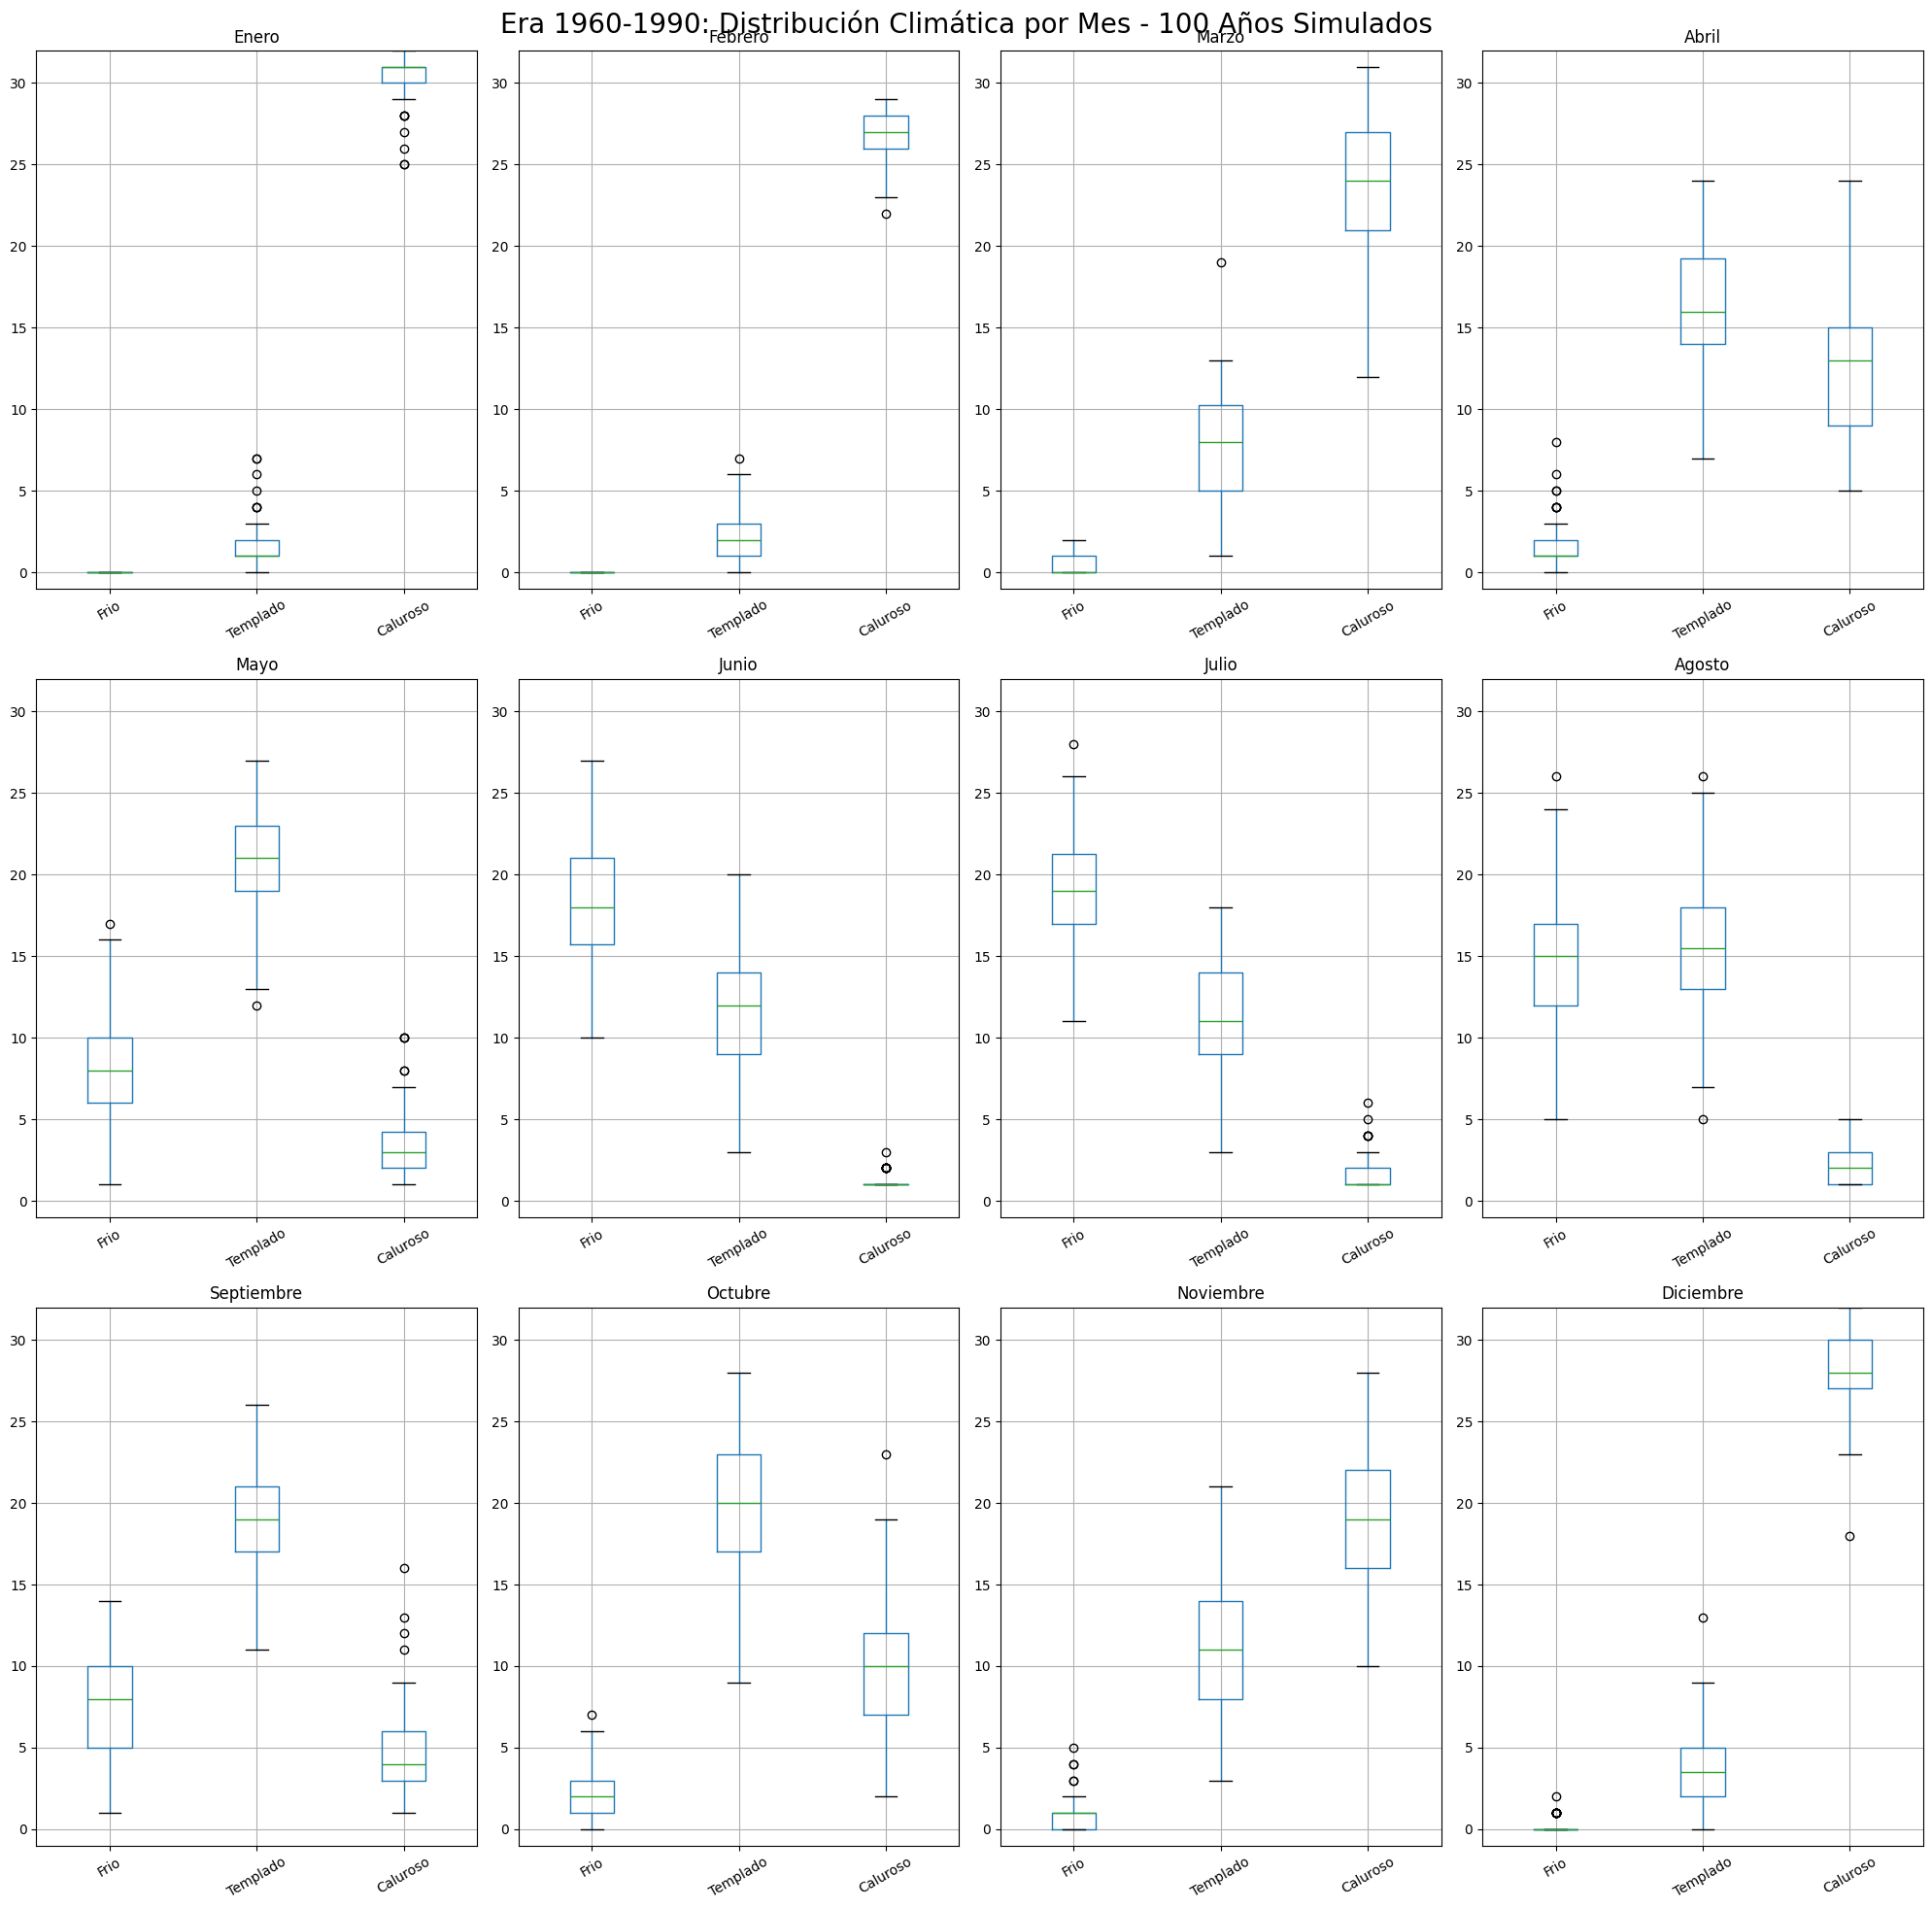

In [170]:
# Era 1
fig1, ax = plt.subplots(3, 4, figsize=(20, 20))
meses_a_graficar = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
nombres_meses = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]
matrices1 = [eneroEra1, febreroEra1, marzoEra1, abrilEra1, mayoEra1, junioEra1, julioEra1, agostoEra1, septiembreEra1, octubreEra1, noviembreEra1, diciembreEra1]

ax_flat = ax.flatten()

resultados_meses1 = {}
resultados_meses2 = {}

for i, m in enumerate(meses_a_graficar):
    resultados_meses1[nombres_meses[i]] = MontecarloParaBoxplot(2, m, matrices1[i], 100)

for i, nombre in enumerate(nombres_meses):
    df_mes = resultados_meses1[nombre]
    # Ahora, usamos el mismo boxplot que para el ejemplo anterior
    df_mes.boxplot(ax=ax_flat[i])
    
    ax_flat[i].set_title(nombre)
    ax_flat[i].set_xticklabels(['Frio', 'Templado', 'Caluroso'], rotation=30)
    ax_flat[i].set_ylim(-1, 32) # Para que todos tengan la misma escala de días

plt.suptitle('Era 1960-1990: Distribución Climática por Mes - 100 Años Simulados', fontsize=20)
plt.tight_layout()
plt.show()



C:\Users\Seba RC\AppData\Local\Temp\ipykernel_11200\1503357439.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


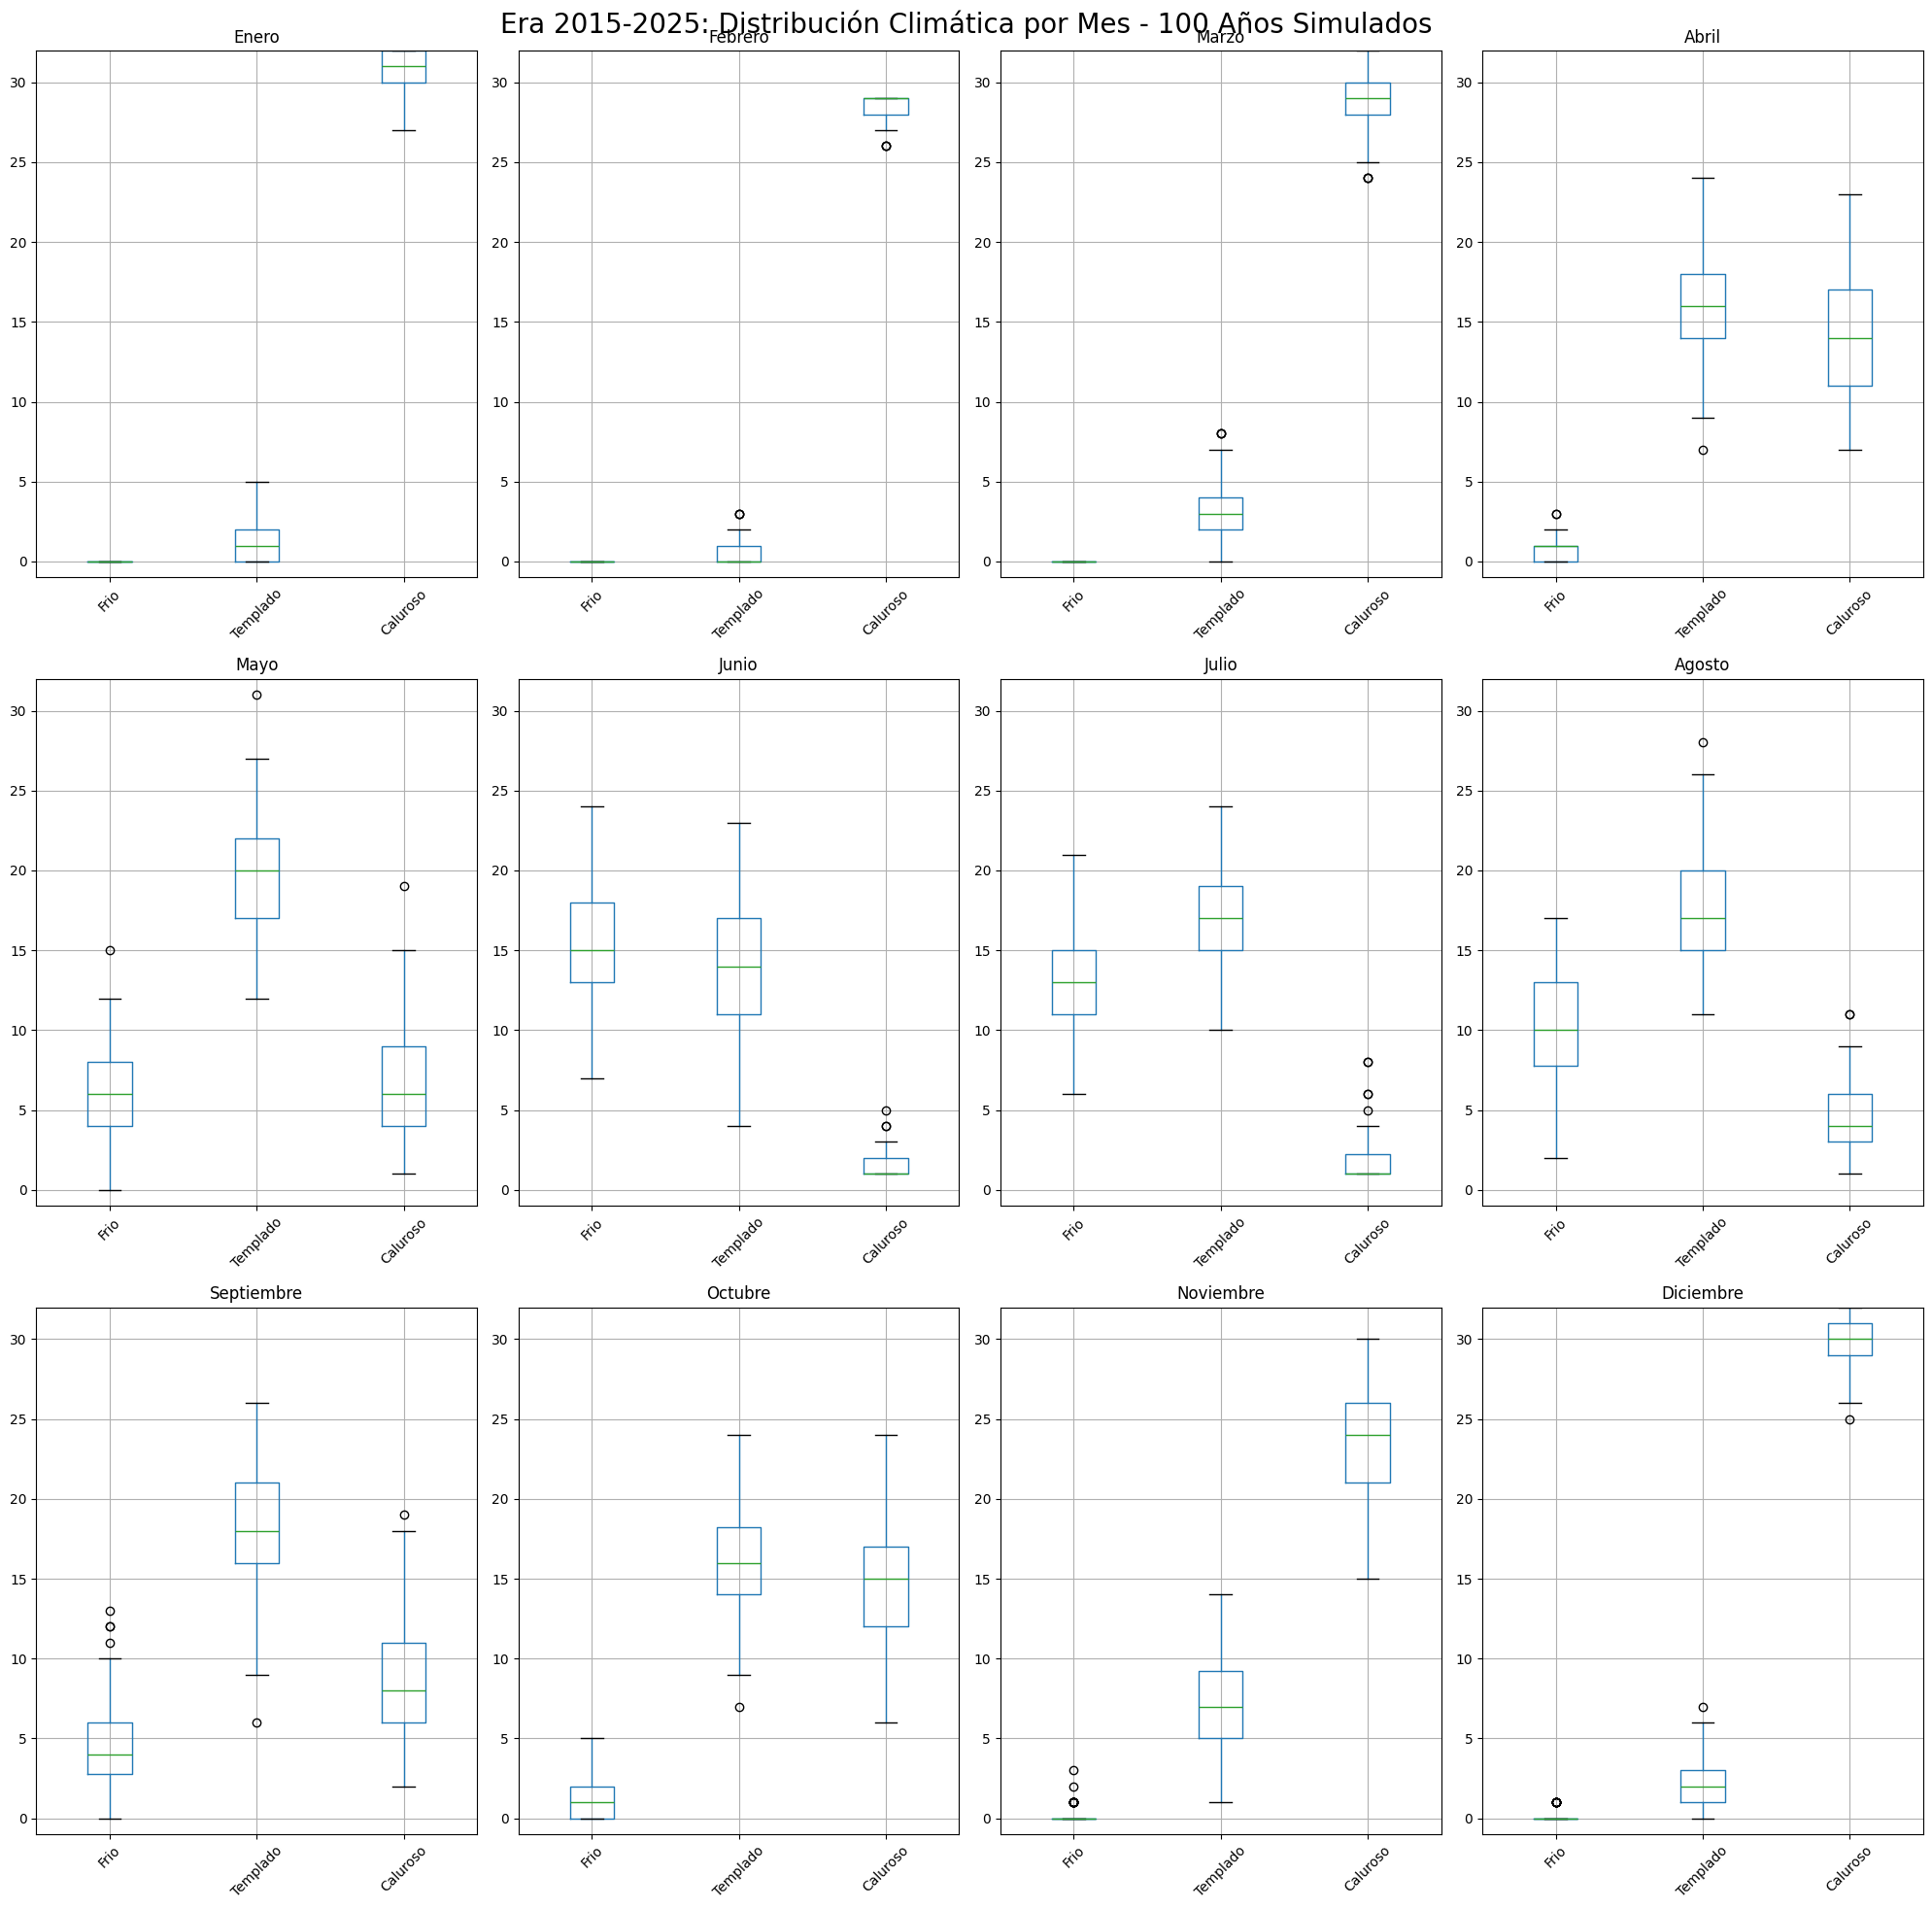

In [169]:
matrices2 = [eneroEra2, febreroEra2, marzoEra2, abrilEra2, mayoEra2, junioEra2, julioEra2, agostoEra2, septiembreEra2, octubreEra2, noviembreEra2, diciembreEra2]

fig2, ax2 = plt.subplots(3, 4, figsize=(20, 20))
ax2_flat = ax2.flatten()

for i, m in enumerate(meses_a_graficar):
    resultados_meses2[nombres_meses[i]] = MontecarloParaBoxplot(2, m, matrices2[i], 100)
for i, nombre in enumerate(nombres_meses):
    df_mes = resultados_meses2[nombre]
    # Ahora, usamos el mismo boxplot que para el ejemplo anterior
    df_mes.boxplot(ax=ax2_flat[i])
    ax2_flat[i].set_title(nombre)
    ax2_flat[i].set_xticklabels(['Frio', 'Templado', 'Caluroso'], rotation=45)
    ax2_flat[i].set_ylim(-1, 32)

fig2.suptitle('Era 2015-2025: Distribución Climática por Mes - 100 Años Simulados', fontsize=20)
fig2.tight_layout()
fig2.show()

Con esto podemos ver que efectivamente, parece que los dias son mas calurosos recientemente. 

Sin embargo, esto no nos da mucha informacion sobre las transiciones en si. Para eso, debemos hacer algunos otros cambios... debemos hacer operaciones vectoriales, y graficar los resultados.

Estado estacionario mes Enero [0.         0.05108213 0.94891787]
Estado estacionario mes Febrero [0.         0.06221198 0.93778802]
Estado estacionario mes Marzo [0.00835073 0.24634656 0.74530271]
Estado estacionario mes Abril [0.05301613 0.56496205 0.38202182]
Estado estacionario mes Mayo [0.27557411 0.66388309 0.0605428 ]
Estado estacionario mes Junio [0.61057174 0.38295577 0.00647249]
Estado estacionario mes Julio [0.63834218 0.35117498 0.01048284]
Estado estacionario mes Agosto [0.46089677 0.50990615 0.02919708]
Estado estacionario mes Septiembre [0.25933247 0.63463424 0.10603328]
Estado estacionario mes Octubre [0.08141962 0.64300626 0.27557411]
Estado estacionario mes Noviembre [0.02793578 0.35933025 0.61273397]
Estado estacionario mes Diciembre [0.00314136 0.13612565 0.86073298]


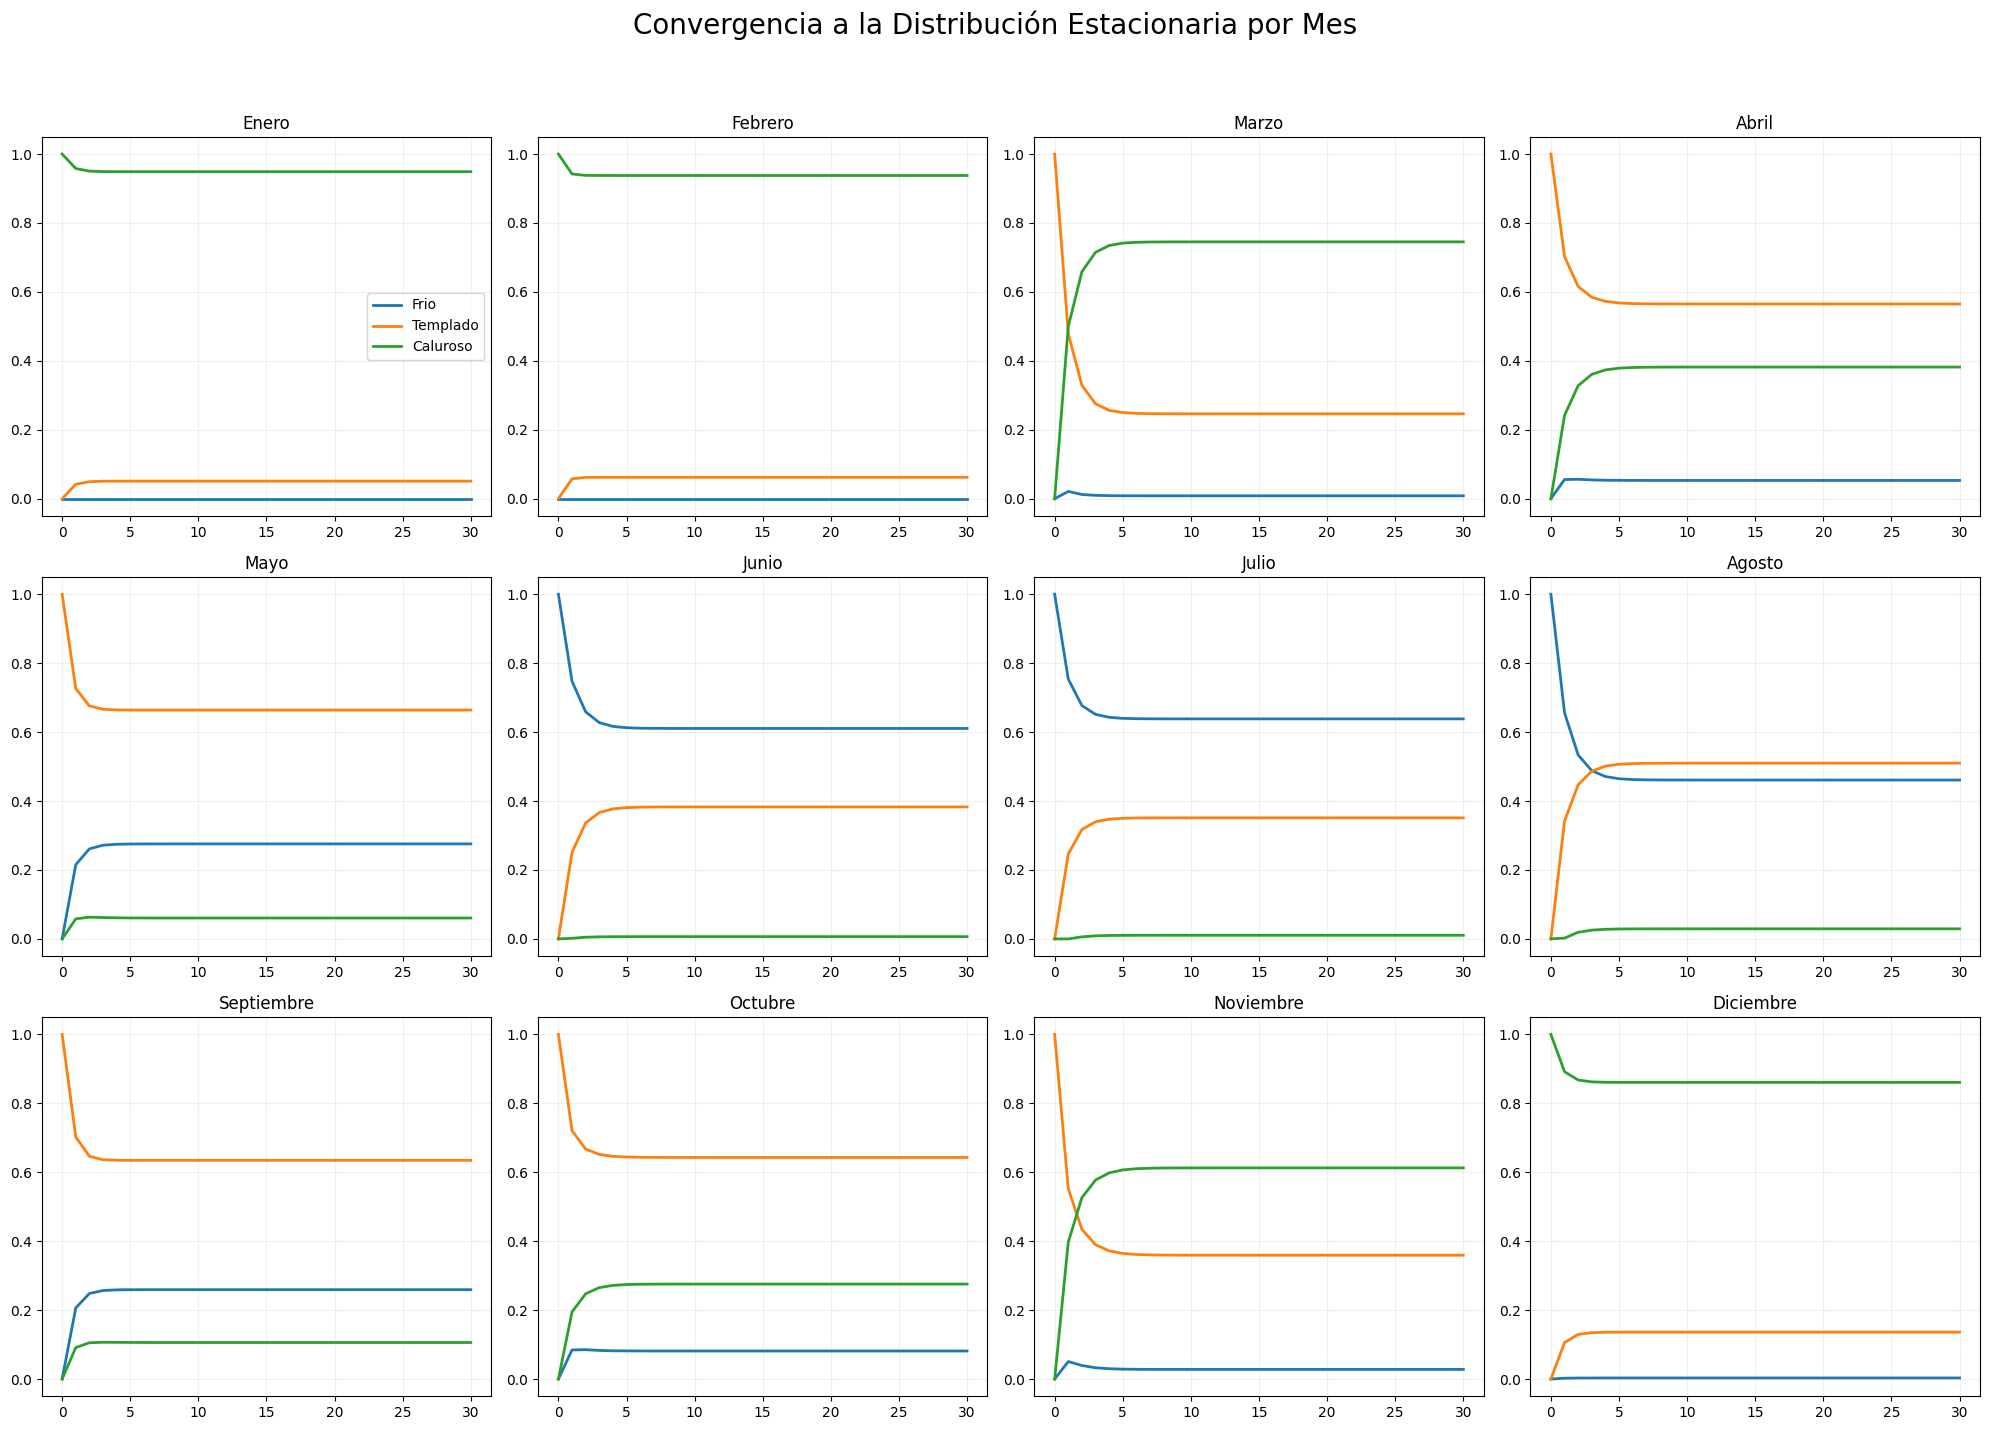

In [187]:
def graficar_evolucion_12_meses(lista_matrices, nombres_meses, pasos=30):
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    ax_flat = axes.flatten()
    estados = ['Frio', 'Templado', 'Caluroso']
    total = []
    
    for i, matrix in enumerate(lista_matrices):
        
        # Enero (0) empieza en Caluroso [0,0,1], Julio (6) en Frío [1,0,0]
        if i in [11, 0, 1]: v = np.array([0, 0, 1]) # Verano
        elif i in [5, 6, 7]: v = np.array([1, 0, 0]) # Invierno
        else: v = np.array([0, 1, 0])                # Transición
        
        historia = [v]
        
        # 2. Cálculo de la evolución
        v_temp = v.copy()
        for _ in range(pasos):
            v_temp = np.dot(v_temp, matrix)
            historia.append(v_temp)
        
        historia = np.array(historia)
        
        # 3. Graficar en el subplot correspondiente
        for j in range(len(estados)):
            ax_flat[i].plot(historia[:, j], label=estados[j], linewidth=2)
        
        print(f'Estado estacionario mes {nombres_meses[i]}', historia[-1])
        
        ax_flat[i].set_title(nombres_meses[i])
        ax_flat[i].set_ylim(-0.05, 1.05)
        ax_flat[i].grid(True, alpha=0.2)
        
        # Solo ponemos leyenda en el primer gráfico para no saturar
        if i == 0:
            ax_flat[i].legend()

        total.append(historia[-1])

    plt.suptitle('Convergencia a la Distribución Estacionaria por Mes', fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return total

# --- Uso ---
matrices_era = [eneroEra1, febreroEra1, marzoEra1, abrilEra1, mayoEra1, junioEra1, 
                julioEra1, agostoEra1, septiembreEra1, octubreEra1, noviembreEra1, diciembreEra1]

resultados1 = graficar_evolucion_12_meses(matrices_era, nombres_meses)

Y ahora lo mismo, pero para la otra era:



Estado estacionario mes Enero [0.         0.03235294 0.96764706]
Estado estacionario mes Febrero [0.         0.02903226 0.97096774]
Estado estacionario mes Marzo [0.         0.11284616 0.88715384]
Estado estacionario mes Abril [0.02443414 0.5406054  0.43496046]
Estado estacionario mes Mayo [0.2        0.66764706 0.13235294]
Estado estacionario mes Junio [0.49240122 0.4893617  0.01823708]
Estado estacionario mes Julio [0.44488712 0.537583   0.01752988]
Estado estacionario mes Agosto [0.33235294 0.56470588 0.10294118]
Estado estacionario mes Septiembre [0.16109422 0.61094225 0.22796353]
Estado estacionario mes Octubre [0.04411765 0.53235294 0.42352941]
Estado estacionario mes Noviembre [0.00902966 0.22997847 0.76099187]
Estado estacionario mes Diciembre [0.00294985 0.07374631 0.92330383]


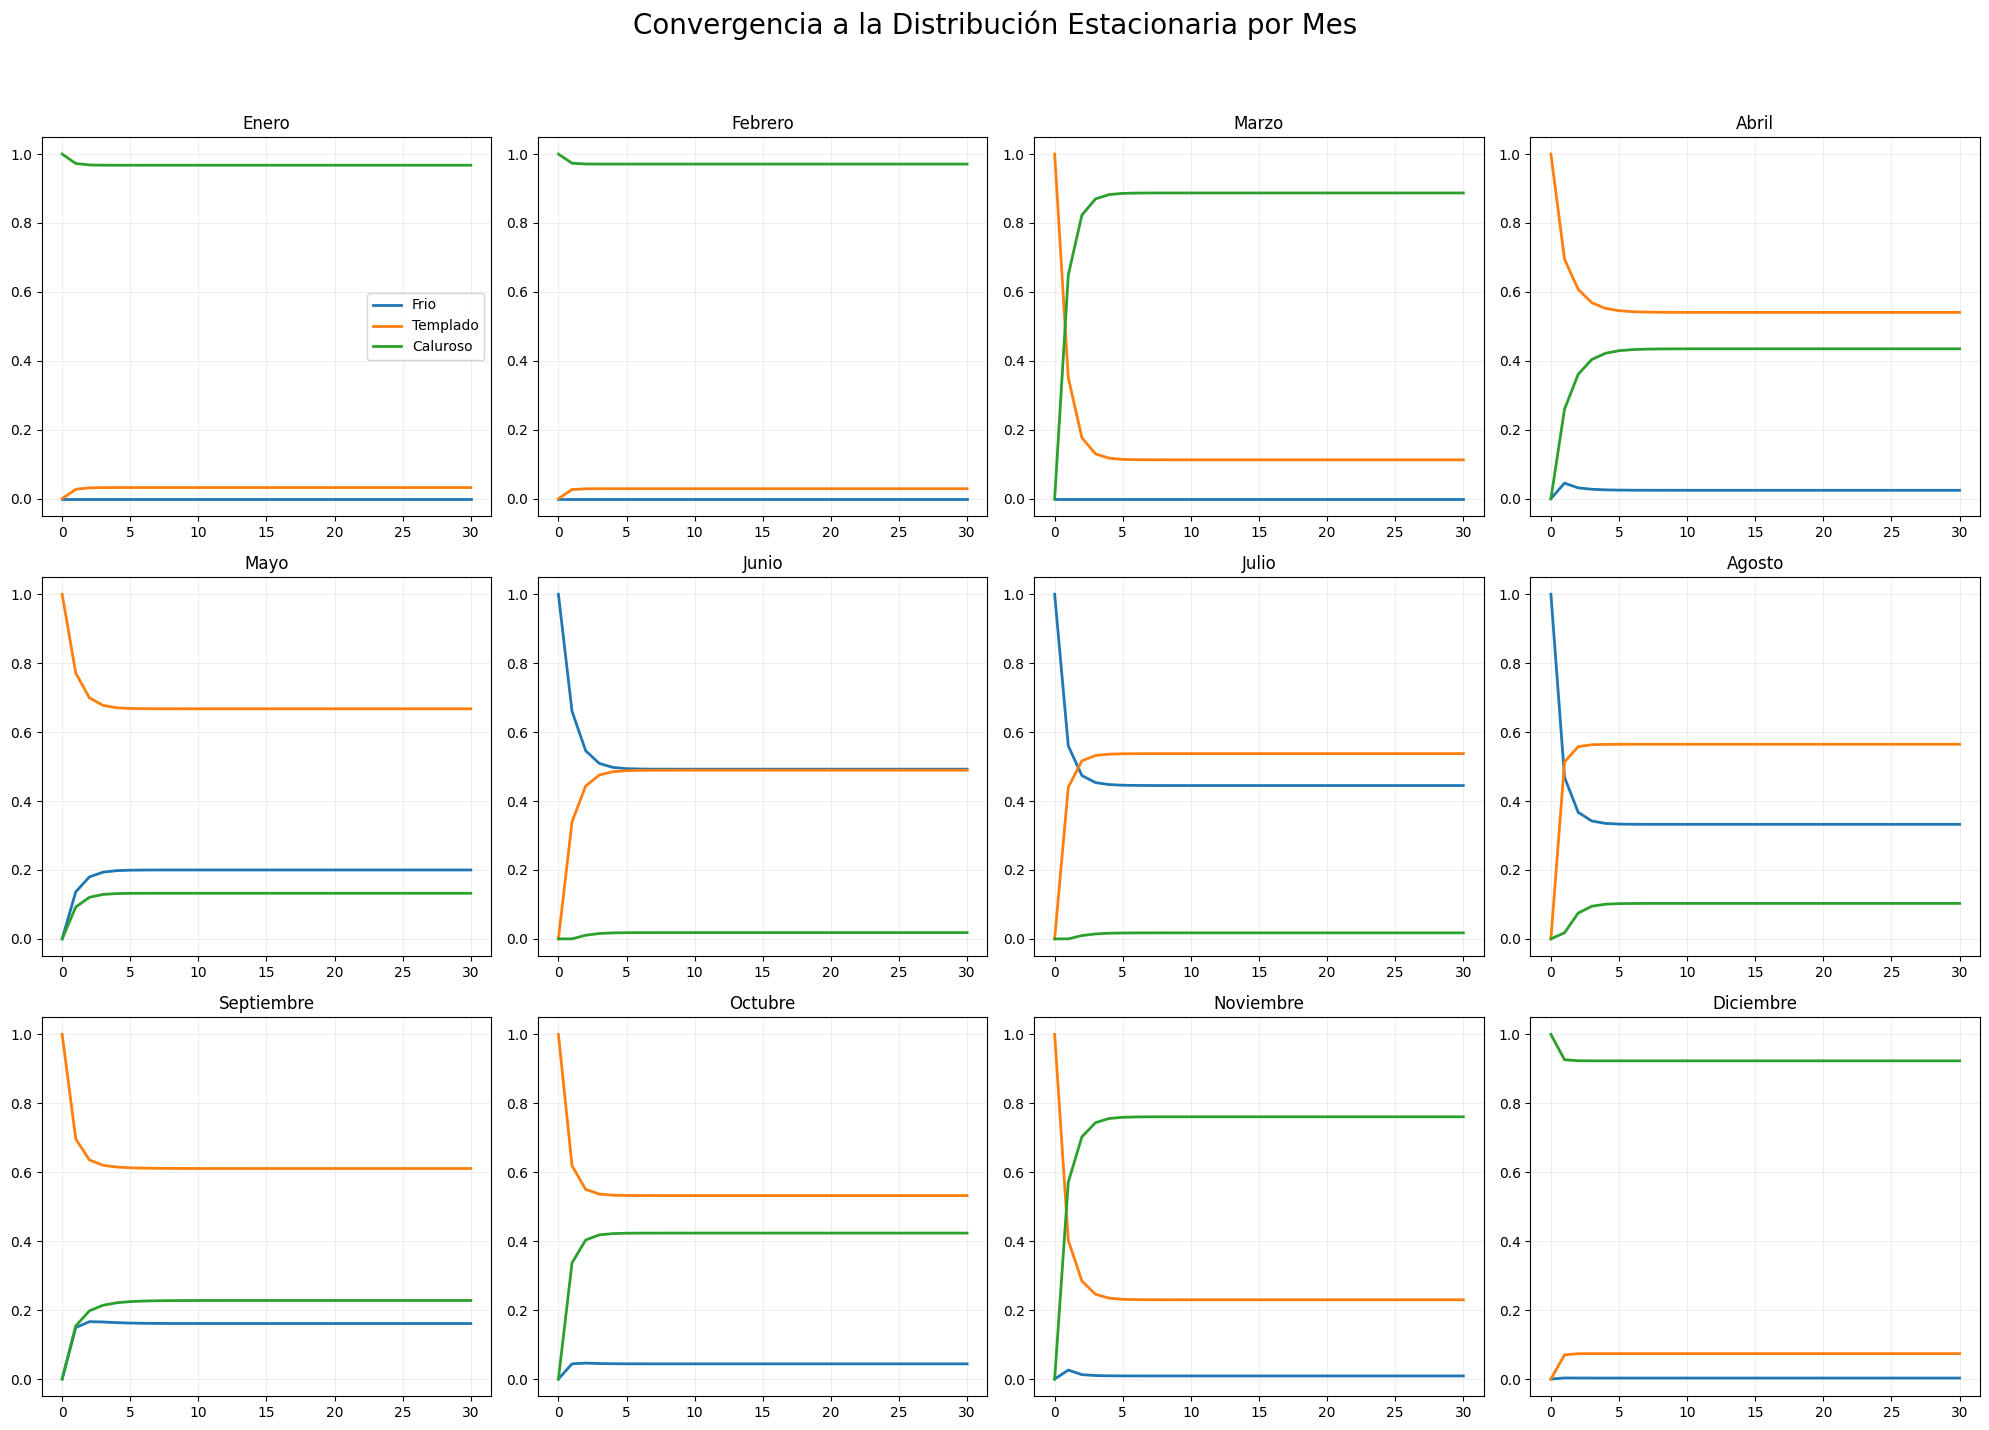

In [188]:
matrices_era2 = [eneroEra2, febreroEra2, marzoEra2, abrilEra2, mayoEra2, junioEra2, 
                julioEra2, agostoEra2, septiembreEra2, octubreEra2, noviembreEra2, diciembreEra2]

resultados2 = graficar_evolucion_12_meses(matrices_era2, nombres_meses)

In [192]:
resultados1Df = pd.DataFrame(resultados1, 
                               columns=['Frio', 'Templado', 'Caluroso'], 
                               index=nombres_meses)

resultados2Df = pd.DataFrame(resultados2, 
                               columns=['Frio', 'Templado', 'Caluroso'], 
                               index=nombres_meses)


display(resultados1Df)
display(resultados2Df)

,Frio,Templado,Caluroso
Enero,0.000000,0.051082,0.948918
Febrero,0.000000,0.062212,0.937788
Marzo,0.008351,0.246347,0.745303
Abril,0.053016,0.564962,0.382022
Mayo,0.275574,0.663883,0.060543
Junio,0.610572,0.382956,0.006472
Julio,0.638342,0.351175,0.010483
Agosto,0.460897,0.509906,0.029197
Septiembre,0.259332,0.634634,0.106033
Octubre,0.081420,0.643006,0.275574


,Frio,Templado,Caluroso
Enero,0.000000,0.032353,0.967647
Febrero,0.000000,0.029032,0.970968
Marzo,0.000000,0.112846,0.887154
Abril,0.024434,0.540605,0.434960
Mayo,0.200000,0.667647,0.132353
Junio,0.492401,0.489362,0.018237
Julio,0.444887,0.537583,0.017530
Agosto,0.332353,0.564706,0.102941
Septiembre,0.161094,0.610942,0.227964
Octubre,0.044118,0.532353,0.423529


Con esto podemos ver que, efectivamente, hoy en dia es mucho mas probable que nos quedemos en un estado de dia caluroso dado que el dia anterior tambien fue caluroso.

Esto tiene sentido con los datos de que, en los ultimos 10 años, hemos tenido los años mas calurosos en la historia de Chile. 

Ahora, a solicitud del profesor, representaré las matrices de transición de ambas eras como grafos.

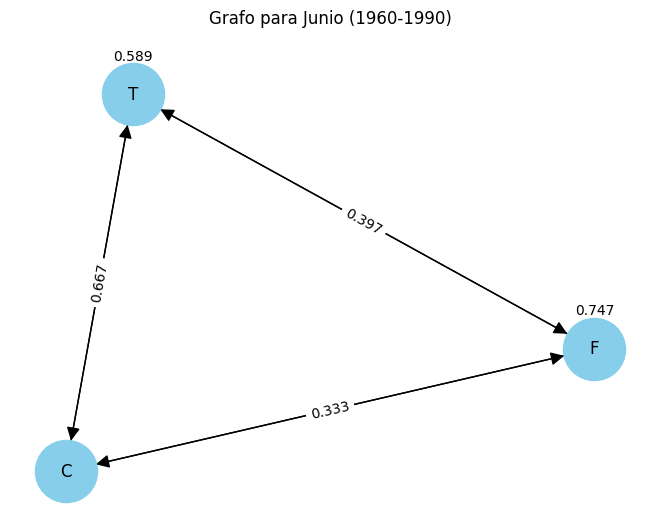

In [209]:
import networkx as nx

states = ['F', 'T', 'C']

G = nx.DiGraph()

# Construir grafo
for i, origin in enumerate(states):
    for j, destination in enumerate(states):
        prob = junioEra1[i][j]
        prob = round(prob, 3)
        if prob > 0:
            G.add_edge(origin, destination, weight=prob, label=prob)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='skyblue', arrowsize=20)
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title('Grafo para Junio (1960-1990)')
plt.show()


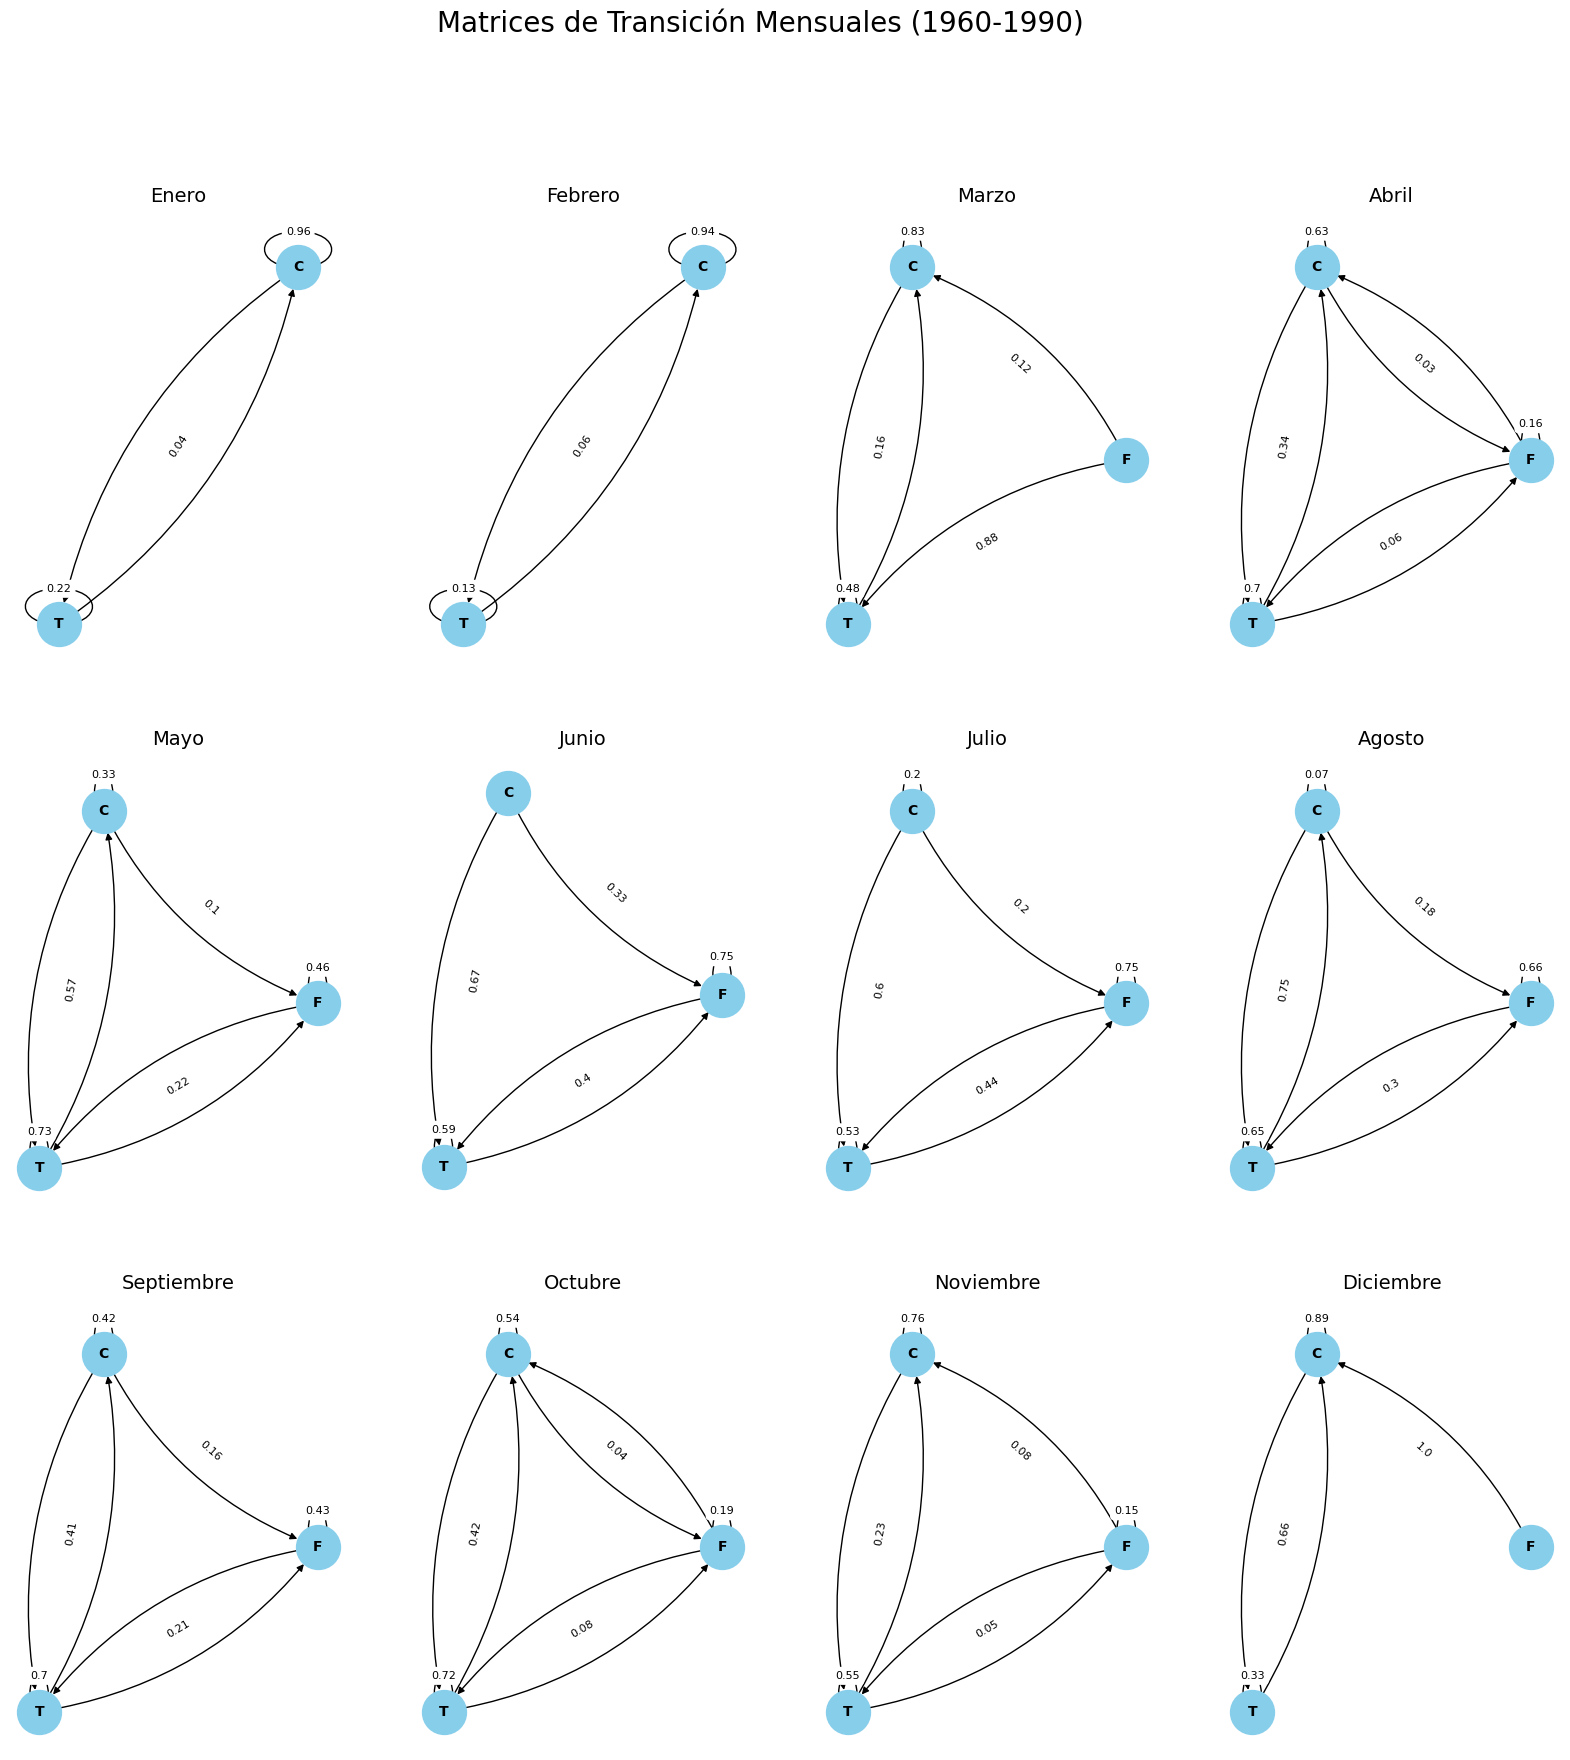

In [222]:
import networkx as nx
import matplotlib.pyplot as plt

states = ['F', 'T', 'C']

G_temp = nx.DiGraph()
G_temp.add_nodes_from(states)
pos = nx.spring_layout(G_temp)

fig, axes = plt.subplots(3, 4, figsize=(20, 20))
ax_flat = axes.flatten()

for i, matriz in enumerate(matrices_era1):
    G = nx.DiGraph()
    
    # Construir grafo para el mes actual
    for row, origin in enumerate(states):
        for col, destination in enumerate(states):
            prob = round(matriz[row][col], 2)
            if prob > 0.02: # Filtro pequeño para evitar ruido visual
                G.add_edge(origin, destination, label=prob)

    # Dibujar en el subplot correspondiente
    plt.sca(ax_flat[i])
    
    # Dibujar nodos y flechas
    nx.draw(G, pos, with_labels=True, node_size=1000, node_color='skyblue', 
            arrowsize=10, font_size=10, font_weight='bold', min_source_margin=5, 
            min_target_margin=5, connectionstyle='arc3,rad=0.2') # Curva suave para ver flechas de ida y vuelta
    
    # Dibujar etiquetas de las aristas
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    
    ax_flat[i].set_title(nombres_meses[i], fontsize=14)

plt.suptitle('Matrices de Transición Mensuales (1960-1990)', fontsize=20)
plt.show()

Y lo mismo para las matrices de 2015-2025:

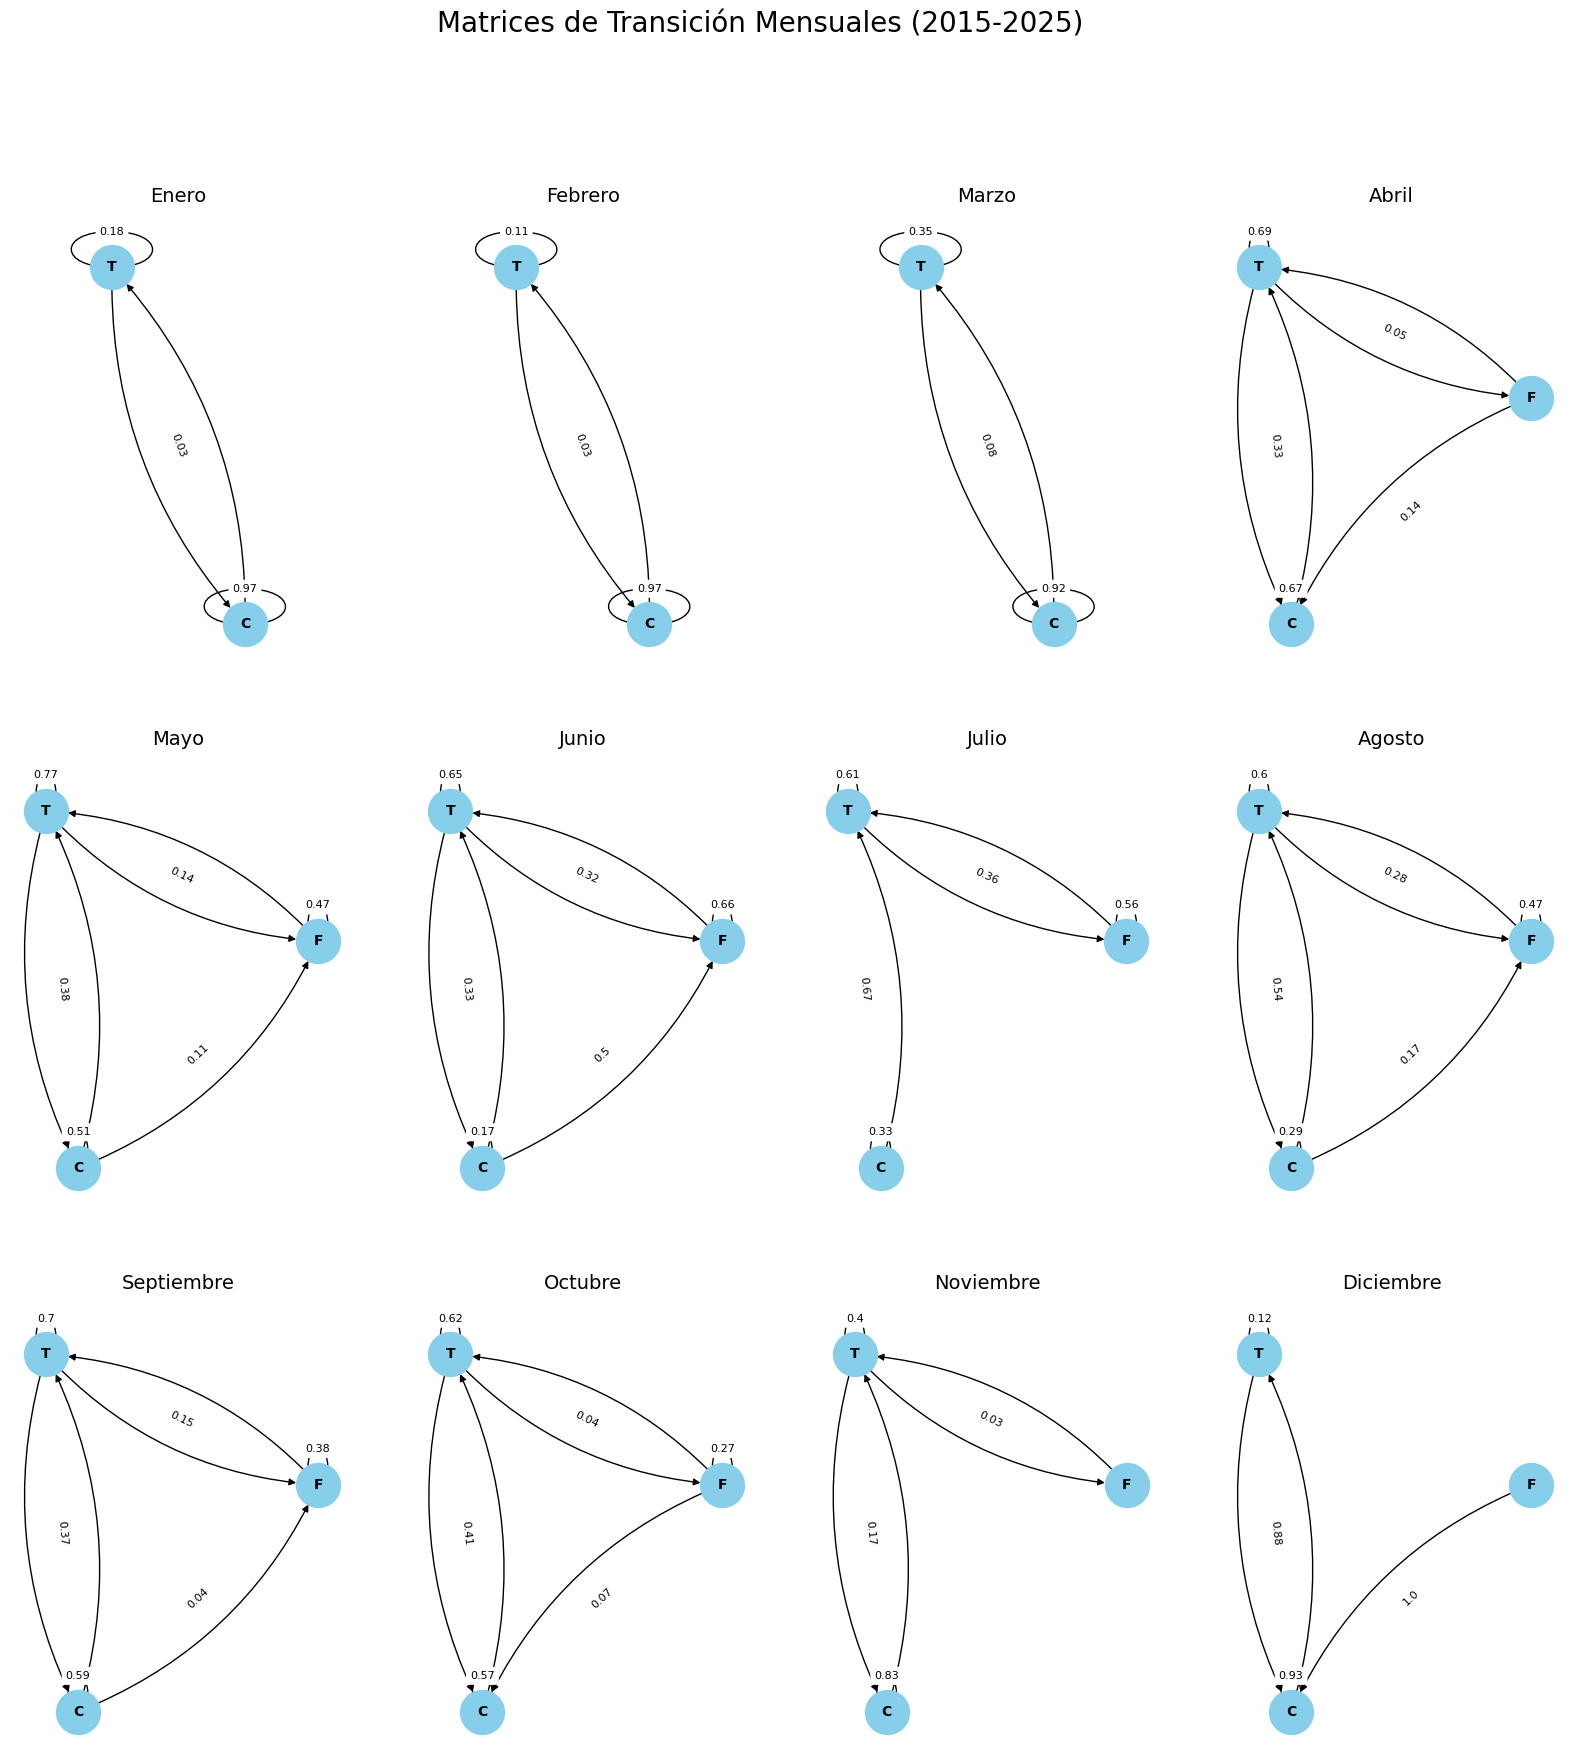

In [221]:
import networkx as nx
import matplotlib.pyplot as plt

states = ['F', 'T', 'C']

G_temp = nx.DiGraph()
G_temp.add_nodes_from(states)
pos = nx.spring_layout(G_temp)

fig, axes = plt.subplots(3, 4, figsize=(20, 20))
ax_flat = axes.flatten()

for i, matriz in enumerate(matrices_era2):
    G = nx.DiGraph()
    
    # Construir grafo para el mes actual
    for row, origin in enumerate(states):
        for col, destination in enumerate(states):
            prob = round(matriz[row][col], 2)
            if prob > 0.02: # Filtro pequeño para evitar ruido visual
                G.add_edge(origin, destination, label=prob)

    # Dibujar en el subplot correspondiente
    plt.sca(ax_flat[i])
    
    # Dibujar nodos y flechas
    nx.draw(G, pos, with_labels=True, node_size=1000, node_color='skyblue', 
            arrowsize=10, font_size=10, font_weight='bold', min_source_margin=5, 
            min_target_margin=5, connectionstyle='arc3,rad=0.2') # Curva suave para ver flechas de ida y vuelta
    
    # Dibujar etiquetas de las aristas
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)
    
    ax_flat[i].set_title(nombres_meses[i], fontsize=14)

plt.suptitle('Matrices de Transición Mensuales (2015-2025)', fontsize=20)
plt.show()